In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../dataset/train.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
df2 = pd.read_csv("../dataset/test.csv")
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

Accuracy: 0.7981520966595593
Logistic Regression Report (threshold=0.4):
               precision    recall  f1-score   support

           0       0.88      0.84      0.86      1033
           1       0.61      0.69      0.65       374

    accuracy                           0.80      1407
   macro avg       0.74      0.76      0.75      1407
weighted avg       0.81      0.80      0.80      1407



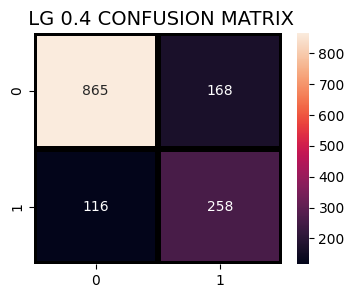

In [3]:
#normal log regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
#chạy test
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
#nhá đại khái thì toàn bộ chỗ bên trên là như file simple model thôi
#cái mô hình log reg này nó đang bị yếu lớp churn, nên là mình sẽ hạ threshold xuống để kéo f1 churn lên
#hạ xuống 04 thay vì 0.5 mặc định nhá
threshold = 0.4
y_pred_log_adj = (y_prob_log >= threshold).astype(int)

#nè thử coi sao
print("Accuracy:", accuracy_score(y_test, y_pred_log_adj))
print("Logistic Regression Report (threshold=0.4):\n", classification_report(y_test, y_pred_log_adj))
#recall cho churn từ 0,57 lên 0.69 nhá há há
#precision thì hơi giảm nhẹ 0.04, chấp nhận trade off ha

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_log_adj), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" LG 0.4 CONFUSION MATRIX",fontsize=14)
plt.show()

Accuracy: 0.7661691542288557
Logistic Regression Report (threshold=0.3):
               precision    recall  f1-score   support

           0       0.91      0.76      0.83      1033
           1       0.54      0.79      0.64       374

    accuracy                           0.77      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.81      0.77      0.78      1407



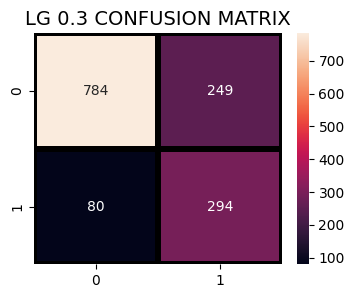

In [4]:
#thử hạ xuống tiếp 0.3 coi sao nè
threshold = 0.3
y_pred_log_adj = (y_prob_log >= threshold).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred_log_adj))
print("Logistic Regression Report (threshold=0.3):\n", classification_report(y_test, y_pred_log_adj))
#vì da ua bảo vơ nhầm còn hơn bỏ sót nên chốt 0.3 nhé

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_log_adj), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("LG 0.3 CONFUSION MATRIX",fontsize=14)
plt.show()

Accuracy: 0.6517412935323383
Logistic Regression Report (threshold=0.3, balanced):
               precision    recall  f1-score   support

           0       0.96      0.55      0.70      1033
           1       0.43      0.94      0.59       374

    accuracy                           0.65      1407
   macro avg       0.70      0.74      0.64      1407
weighted avg       0.82      0.65      0.67      1407



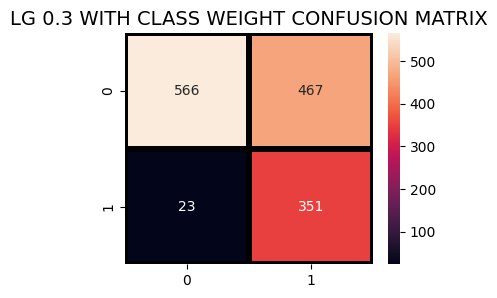

In [5]:
#thế này nhá, trong một bài toán churn thì thường nhóm KH churn sẽ là thiểu số
#mà các mô hình thường sẽ bị lệch về nửa đa số kia
#nên giờ mình thử thêm class_weight='balanced' vào xem sao
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
#chốt threshold 3
threshold = 0.3
y_pred_log_adj = (y_prob_log >= threshold).astype(int)
#kết quả nè
print("Accuracy:", accuracy_score(y_test, y_pred_log_adj))
print("Logistic Regression Report (threshold=0.3, balanced):\n", classification_report(y_test, y_pred_log_adj))

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_log_adj), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("LG 0.3 WITH CLASS WEIGHT CONFUSION MATRIX",fontsize=14)
plt.show()

Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.96      0.55      0.70      1033
           1       0.43      0.94      0.59       374

    accuracy                           0.65      1407
   macro avg       0.70      0.74      0.65      1407
weighted avg       0.82      0.65      0.67      1407



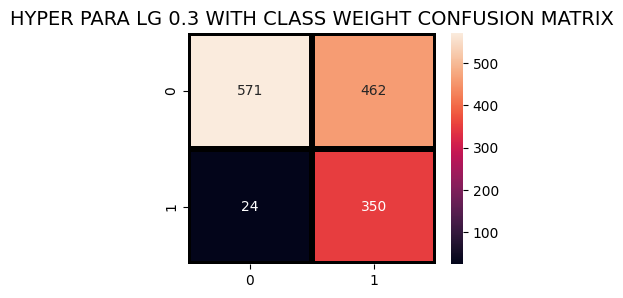

In [6]:
#t biết là cái phương án này bọn mình đã bảo bỏ đi rồi (lúc t nói trước khi vào tiết java)
#nhưng thôi đã thử rồi thì cứ vứt vào đây
#kq y chang cell bên trên thôi vì bộ số tốt nhất trong bài này tình cờ lại giống với bộ mặc định lollll
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1'   # hoặc 'recall' nếu bạn muốn tối ưu recall cho churn
)
#train này
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_
#vẫn giữ threshold 0.3 nhé
y_prob = best_model.predict_proba(X_test)[:,1]
y_pred_hyper = (y_prob >= 0.3).astype(int)

print(classification_report(y_test, y_pred_hyper))

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_hyper), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("HYPER PARA LG 0.3 WITH CLASS WEIGHT CONFUSION MATRIX",fontsize=14)
plt.show()

In [7]:
#tổng kết
data = {
    "Model": [
        "Logistic (original, threshold=0.5)",
        "Logistic (threshold=0.4)",
        "Logistic (threshold=0.3)",
        "Logistic (threshold=0.3 + balanced)"
    ],
    "TN": [865, 865, 784, 566],
    "FN": [116, 116, 80, 23],
    "FP": [168, 168, 249, 467],
    "TP": [258, 258, 294, 351]
}

df_results = pd.DataFrame(data)

styled_results = (
    df_results.style
    .background_gradient(cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse")
        ]}
    ])
)

styled_results

,Model,TN,FN,FP,TP
0,"Logistic (original, threshold=0.5)",865,116,168,258
1,Logistic (threshold=0.4),865,116,168,258
2,Logistic (threshold=0.3),784,80,249,294
3,Logistic (threshold=0.3 + balanced),566,23,467,351


In [2]:
import pandas as pd

data = {
    "Model": [
        "Logistic Regression (normal)",
        "Logistic Regression (threshold=0.3)",
        "Logistic Regression (class weight balanced)",
        "Logistic Regression (hyperparameter)"
    ],
    "Accuracy": [0.80, 0.77, 0.65, 0.65],
    "Precision_churn": [0.65, 0.54, 0.43, 0.43],
    "Recall_churn": [0.57, 0.79, 0.94, 0.94],
    "F1_churn": [0.61, 0.64, 0.59, 0.59]
}
df = pd.DataFrame(data)

print(df.to_string(index=False))


                                      Model  Accuracy  Precision_churn  Recall_churn  F1_churn
               Logistic Regression (normal)      0.80             0.65          0.57      0.61
        Logistic Regression (threshold=0.3)      0.77             0.54          0.79      0.64
Logistic Regression (class weight balanced)      0.65             0.43          0.94      0.59
       Logistic Regression (hyperparameter)      0.65             0.43          0.94      0.59
